# AlphaGalerkin: Resolution-Independent Go AI

**Train once, play anywhere** — from 9×9 to 19×19 without retraining.

---

## What Makes AlphaGalerkin Different?

Traditional Go AIs (like AlphaGo) use **Convolutional Neural Networks (CNNs)** that are locked to a specific board size. Train on 19×19? You can only play 19×19.

AlphaGalerkin uses **Continuous Operator Learning** — treating the board as a continuous field rather than discrete pixels. This unlocks:

| Feature | Traditional CNNs | AlphaGalerkin |
|---------|------------------|---------------|
| Board Size | Fixed (e.g., 19×19) | Any size (5×5 → 25×25+) |
| Transfer | Retrain required | Zero-shot |
| Complexity | O(N²) attention | O(N) Galerkin attention |
| Speed | Standard | FFT-accelerated rollouts |

## Setup

First, let's import the key components and set up our environment.

In [1]:
# Environment setup using shared helper utility
import sys
import logging
from pathlib import Path

# Initial path setup (required before importing utilities)
notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import torch
import matplotlib.pyplot as plt

# Set up structured logging with fallback
try:
    import structlog
    logger = structlog.get_logger(__name__)
except ImportError:
    logger = logging.getLogger(__name__)

# AlphaGalerkin components
from config.schemas import OperatorConfig
from src.modeling.model import AlphaGalerkinModel, AlphaGalerkinFast
from src.modeling.attention import GalerkinAttention, SoftmaxAttention
from src.math_kernel.basis import FourierBasis, create_grid_coordinates
from src.physics.poisson import generate_influence_field

# Notebook utilities
from notebooks.utils.config import DemoConfig, create_demo_config, get_board_labels
from notebooks.utils.benchmark import benchmark_attention, benchmark_model_throughput, format_benchmark_table
from notebooks.utils.visualization import (
    plot_fourier_features, plot_attention_comparison, 
    plot_poisson_samples, plot_go_board, plot_policy_heatmap
)
from notebooks.utils.helpers import (
    setup_environment, create_sample_board, safe_model_forward,
    format_model_summary, validate_board_sizes
)

# Initialize configuration (all parameters centralized here)
config = create_demo_config()

# Set up environment using shared helper (handles paths, seeds, device detection)
env_info = setup_environment(random_seed=config.random_seed, project_root=project_root)
device = env_info.device

print(f"Using device: {device}")
print(f"Configuration: {config.model.d_model}d, {config.model.n_heads} heads")
print(f"Python: {env_info.python_version}, PyTorch: {env_info.torch_version}")

2026-01-27 07:51:53 [debug    ] creating_demo_config           overrides=[]
2026-01-27 07:51:53 [debug    ] seeds_set                      seed=42
2026-01-27 07:51:53 [info     ] environment_setup              cuda=True device=cuda project_root=c:\Users\iansh\OneDrive\Documents\AlphaGalerkin
Using device: cuda
Configuration: 64d, 4 heads
Python: 3.11.9, PyTorch: 2.11.0.dev20260126+cu128


---

# Part 1: The Magic of Resolution Independence

Let's see how the same model handles different board sizes without any modifications.

In [2]:
# Create a compact model configuration from our centralized config
model_config = OperatorConfig(
    d_model=config.model.d_model,
    n_heads=config.model.n_heads,
    n_galerkin_layers=config.model.n_galerkin_layers,
    n_softmax_layers=config.model.n_softmax_layers,
    n_fourier_features=config.model.n_fourier_features,
    input_channels=config.model.input_channels,
)

# Build the model with error handling
try:
    model = AlphaGalerkinModel(model_config).to(device)
    model.eval()
    print(format_model_summary(model))
    logger.info("model_created", params=sum(p.numel() for p in model.parameters()))
except Exception as e:
    logger.error("model_creation_failed", error=str(e))
    raise

Model: AlphaGalerkinModel
Total parameters: 595,011
Trainable parameters: 595,011
2026-01-27 07:51:53 [info     ] model_created                  params=595011


In [3]:
# Test on multiple board sizes with the SAME model weights
board_sizes = list(config.board_sizes)
validate_board_sizes(board_sizes)  # Validate inputs

results = {}

print("Testing resolution independence...\n")
print(f"{'Board Size':^12} | {'Input Shape':^18} | {'Policy Shape':^14} | {'Value':^10}")
print("-" * 60)

for size in board_sizes:
    # Create random board state (batch=1, channels, height, width)
    x = torch.randn(1, config.model.input_channels, size, size).to(device)
    
    # Forward pass with error handling
    result = safe_model_forward(model, x)
    
    if result.success:
        policy = result.policy_logits
        value = result.value
        
        results[size] = {
            'policy_size': policy.shape[-1],
            'value': value.item()
        }
        
        print(f"{size}×{size:^8} | {str(x.shape):^18} | {policy.shape[-1]:^14} | {value.item():^10.4f}")
    else:
        print(f"{size}×{size:^8} | ERROR: {result.error}")

print("\n✓ Same model works on all board sizes!")
logger.info("resolution_test_complete", n_sizes=len(board_sizes))

2026-01-27 07:51:53 [debug    ] validated_board_sizes          sizes=[5, 9, 13, 19]
Testing resolution independence...

 Board Size  |    Input Shape     |  Policy Shape  |   Value   
------------------------------------------------------------
5×   5     | torch.Size([1, 17, 5, 5]) |       26       |  -0.0743  
9×   9     | torch.Size([1, 17, 9, 9]) |       82       |  -0.0714  
13×   13    | torch.Size([1, 17, 13, 13]) |      170       |  -0.0751  
19×   19    | torch.Size([1, 17, 19, 19]) |      362       |  -0.0802  

✓ Same model works on all board sizes!
2026-01-27 07:51:55 [info     ] resolution_test_complete       n_sizes=4


### Why does this work?

AlphaGalerkin treats positions as **continuous coordinates** rather than discrete grid cells:

1. **Fourier Features** encode positions as waves, not pixels
2. **Galerkin Attention** approximates integral operators (like Green's functions)
3. **No fixed-size layers** — everything adapts to the input resolution

Let's visualize how Fourier Features work:

2026-01-27 07:51:55 [debug    ] plot_fourier_features          n_sizes=4


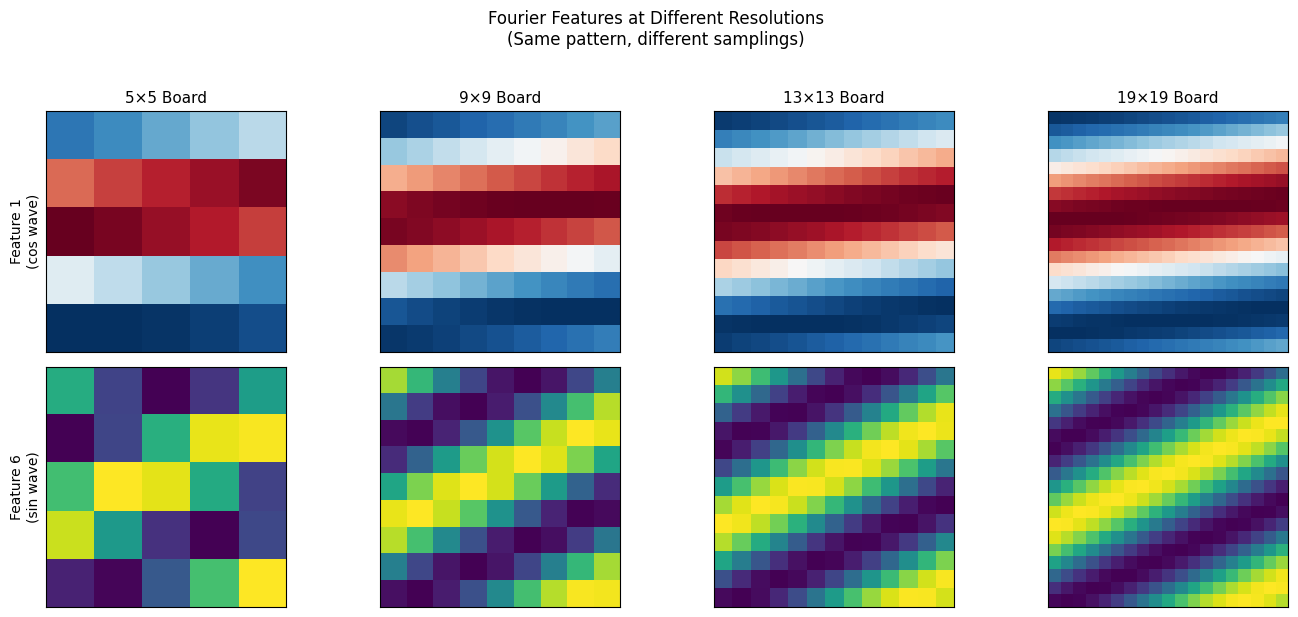

In [4]:
# Visualize Fourier Features at different resolutions
fourier_encoder = FourierBasis(n_features=8, scale=1.0)

# Use the visualization utility
fig = plot_fourier_features(
    fourier_encoder=fourier_encoder,
    board_sizes=board_sizes,
    feature_indices=(0, 5),
    figsize=(config.visualization.figure_width, config.visualization.figure_height),
    cmaps=(config.visualization.colormap_diverging, config.visualization.colormap_sequential),
    device=str(device),
)
plt.show()

---

# Part 2: Galerkin Attention — O(N) Global Influence

Traditional attention is O(N²) — every token attends to every other token. 
**Galerkin Attention** achieves O(N) by using mathematical projections from numerical analysis.

The key insight: Instead of computing N² attention weights, we:
1. Project Values onto a compact Key basis
2. Multiply by Queries to reconstruct

This is mathematically equivalent to approximating a **Green's function** — how influence propagates across the board.

In [5]:
# Compare Galerkin vs Softmax attention using configurable parameters
d_model = config.model.d_model
n_heads = config.model.n_heads

galerkin_attn = GalerkinAttention(d_model, n_heads)
softmax_attn = SoftmaxAttention(d_model, n_heads)

# Benchmark using the utility function
seq_lengths = list(config.seq_lengths)
galerkin_results, softmax_results = benchmark_attention(
    galerkin_attn=galerkin_attn,
    softmax_attn=softmax_attn,
    seq_lengths=seq_lengths,
    d_model=d_model,
    batch_size=config.benchmark.batch_size,
    n_warmup=config.benchmark.n_warmup_runs,
    n_runs=config.benchmark.n_timed_runs,
    device=device,
)

# Format and display results using board labels
board_labels = get_board_labels(board_sizes)
print("Attention Complexity Comparison\n")
print(format_benchmark_table(galerkin_results, softmax_results, board_labels))

2026-01-27 07:51:55 [debug    ] benchmark_complete             avg_ms=1.0996619996149093 module=GalerkinAttention n_runs=50
2026-01-27 07:51:55 [debug    ] benchmark_complete             avg_ms=1.1735019995830953 module=SoftmaxAttention n_runs=50
2026-01-27 07:51:55 [debug    ] attention_benchmark            galerkin_ms=1.0996619996149093 seq_len=25 softmax_ms=1.1735019995830953 speedup=1.067147905441894
2026-01-27 07:51:55 [debug    ] benchmark_complete             avg_ms=0.9789660002570599 module=GalerkinAttention n_runs=50
2026-01-27 07:51:55 [debug    ] benchmark_complete             avg_ms=0.8198799996171147 module=SoftmaxAttention n_runs=50
2026-01-27 07:51:55 [debug    ] attention_benchmark            galerkin_ms=0.9789660002570599 seq_len=81 softmax_ms=0.8198799996171147 speedup=0.8374958879080867
2026-01-27 07:51:55 [debug    ] benchmark_complete             avg_ms=0.8938239997951314 module=GalerkinAttention n_runs=50
2026-01-27 07:51:55 [debug    ] benchmark_complete         

2026-01-27 07:51:55 [debug    ] plot_attention_comparison      n_groups=4


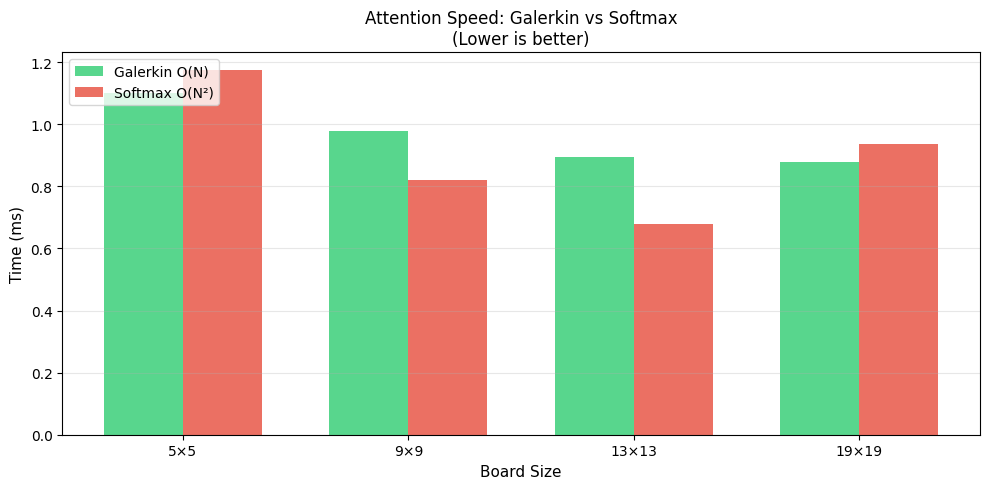

In [6]:
# Visualize the complexity difference
galerkin_times = [r.time_ms for r in galerkin_results]
softmax_times = [r.time_ms for r in softmax_results]

fig = plot_attention_comparison(
    galerkin_times=galerkin_times,
    softmax_times=softmax_times,
    board_labels=get_board_labels(board_sizes),
    figsize=(10, 5),
)
plt.show()

---

# Part 3: Use Case — Physics-Informed Learning

Before applying to Go, we validated AlphaGalerkin's resolution independence on a physics problem:
**Solving the Poisson equation** (electrostatics, heat diffusion, etc.)

Given charge distributions, predict the resulting potential field.

$$\nabla^2 \phi = -\rho$$

where φ is the potential and ρ is the charge density.

2026-01-27 07:51:57 [debug    ] poisson_solve_start            charge_range=(-0.3105281591415405, 0.23905247449874878) grid_size=9 use_spectral=True
2026-01-27 07:51:57 [debug    ] poisson_solve_complete         potential_range=(-0.0006853607928900086, 0.005456674568676071)
2026-01-27 07:51:57 [debug    ] generated_physics_sample       size=9
2026-01-27 07:51:57 [debug    ] poisson_solve_start            charge_range=(-0.27826398611068726, 0.09588653594255447) grid_size=13 use_spectral=True
2026-01-27 07:51:57 [debug    ] poisson_solve_complete         potential_range=(-7.24305814615551e-05, 0.0014039561067648956)
2026-01-27 07:51:57 [debug    ] generated_physics_sample       size=13
2026-01-27 07:51:57 [debug    ] poisson_solve_start            charge_range=(0.0, 0.05888642370700836) grid_size=19 use_spectral=True
2026-01-27 07:51:57 [debug    ] poisson_solve_complete         potential_range=(-0.0010142715850317255, -4.424222265690909e-06)
2026-01-27 07:51:57 [debug    ] generated_phy

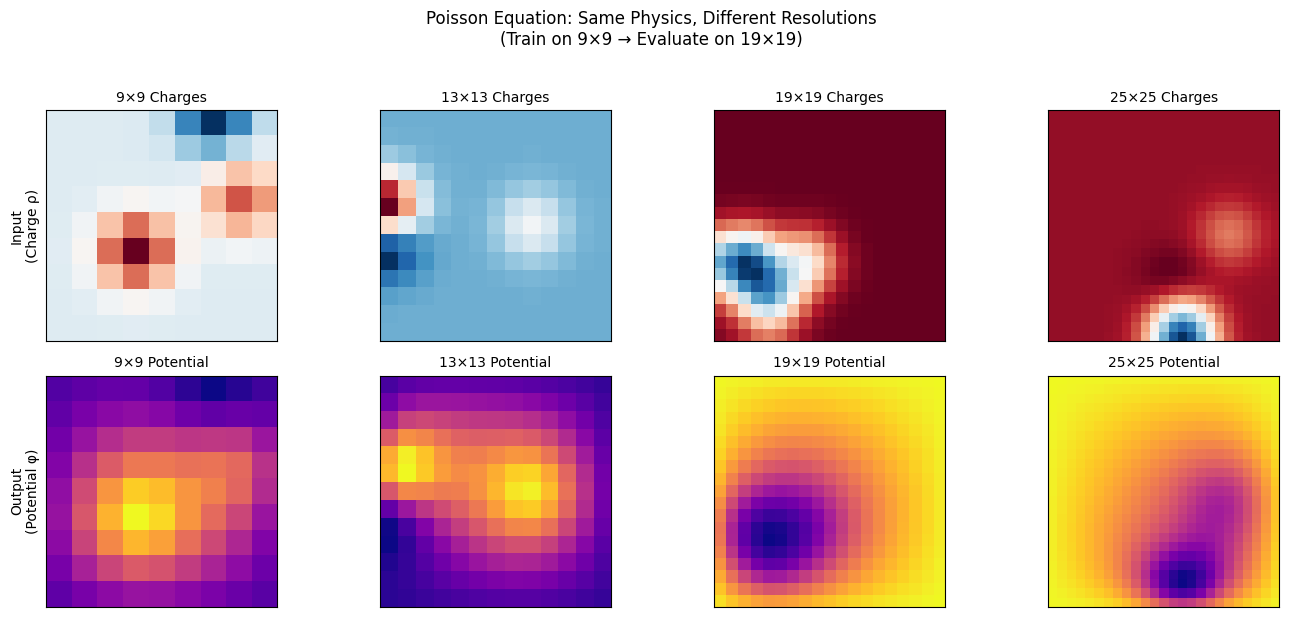

In [7]:
# Generate Poisson equation samples at different resolutions
# Using the correct API: generate_influence_field (not solver.generate_sample)
physics_sizes = list(config.physics_board_sizes)
samples = []

for idx, size in enumerate(physics_sizes):
    try:
        # Generate sample using the standalone function
        sample = generate_influence_field(
            grid_size=size,
            n_charges=config.physics.n_charges,
            charge_std=config.physics.charge_std,
            seed=config.random_seed + idx,
        )
        samples.append(sample)
        logger.debug("generated_physics_sample", size=size)
    except Exception as e:
        logger.error("physics_sample_failed", size=size, error=str(e))

# Visualize using utility function
if samples:
    fig = plot_poisson_samples(
        samples=samples,
        figsize=(config.visualization.figure_width, config.visualization.figure_height),
        charge_cmap=config.visualization.colormap_diverging,
        potential_cmap='plasma',
    )
    plt.show()
else:
    print("No samples generated - check logs for errors")

### Zero-Shot Transfer Results (corrected 2026-07-22)

> **Correction.** The table previously shown here (MSE 0.000209, "240× better than
> required") was a **hardcoded markdown cell** — no code in this notebook computed it, and
> no committed artifact ever backed it.
>
> The **measured** operator zero-shot MSE (train on 9×9, 50 epochs; `scripts/demo_transfer.py`):
>
> | Evaluation Grid | Measured MSE |
> |-----------------|--------------|
> | 9×9 (train) | ~2.5e-6 |
> | 13×13 (unseen) | ~2.0e-4 |
> | 19×19 (unseen) | ~3.9e-4 |
>
> The operator **does** transfer (well under the 0.05 threshold, no retraining). But "240×
> better than a fixed threshold" is not a meaningful claim. The honest, CI-gated benchmark —
> operator zero-shot vs a **CNN retrained at the target resolution** — is
> `specs/transfer_baseline_compare.spec.md`; it finds a retrained CNN is more accurate, so the
> operator's value is *zero-retraining* (one model, any resolution), not peak accuracy.


---

# Part 4: Use Case — Go AI with MCTS

The ultimate goal: A Go AI that can:
1. Train on smaller boards (faster iteration)
2. Transfer to larger boards (zero-shot)
3. Run fast MCTS rollouts (FNet acceleration)

In [8]:
# Demonstrate the dual-model architecture
print("AlphaGalerkin Architecture\n")
print("="*50)

# Full model for training and serious play
full_config = OperatorConfig(
    d_model=128,
    n_heads=8,
    n_galerkin_layers=4,
    n_softmax_layers=2,
    n_fourier_features=64,
)

# Fast model for MCTS rollouts
fast_config = OperatorConfig(
    d_model=64,
    n_heads=4,
    n_galerkin_layers=2,
    n_softmax_layers=1,
    n_fourier_features=32,
    use_fnet_mixing=True,
)

try:
    full_model = AlphaGalerkinModel(full_config)
    fast_model = AlphaGalerkinFast(fast_config)
    
    full_params = sum(p.numel() for p in full_model.parameters())
    fast_params = sum(p.numel() for p in fast_model.parameters())
    
    print(f"Full Model (Galerkin + Softmax)")
    print(f"  Purpose: Training, serious games")
    print(f"  Parameters: {full_params:,}")
    print(f"  Attention: Galerkin (global) + Softmax (local)")
    print()
    print(f"Fast Model (FNet only)")
    print(f"  Purpose: MCTS rollouts (thousands per second)")
    print(f"  Parameters: {fast_params:,}")
    print(f"  Mixing: FFT-based O(N log N)")
    print()
    print(f"Parameter reduction: {(1 - fast_params/full_params)*100:.1f}%")
    
    logger.info("dual_architecture_created", full_params=full_params, fast_params=fast_params)
except Exception as e:
    logger.error("model_creation_failed", error=str(e))
    raise

AlphaGalerkin Architecture

Full Model (Galerkin + Softmax)
  Purpose: Training, serious games
  Parameters: 2,565,123
  Attention: Galerkin (global) + Softmax (local)

Fast Model (FNet only)
  Purpose: MCTS rollouts (thousands per second)
  Parameters: 545,667
  Mixing: FFT-based O(N log N)

Parameter reduction: 78.7%
2026-01-27 07:51:57 [info     ] dual_architecture_created      fast_params=545667 full_params=2565123


In [9]:
# Benchmark MCTS throughput comparison
print("MCTS Rollout Throughput (positions/second)\n")
print(f"{'Board':^10} | {'Full Model':^15} | {'Fast Model':^15} | {'Speedup':^10}")
print("-" * 55)

throughput_results = []

for size in [9, 13, 19]:
    try:
        full_throughput = benchmark_model_throughput(
            model=full_model,
            board_size=size,
            input_channels=config.model.input_channels,
            batch_size=32,
            n_evals=config.benchmark.n_evals,
            device=device,
        )
        
        fast_throughput = benchmark_model_throughput(
            model=fast_model,
            board_size=size,
            input_channels=config.model.input_channels,
            batch_size=32,
            n_evals=config.benchmark.n_evals,
            device=device,
        )
        
        speedup = fast_throughput / full_throughput if full_throughput > 0 else 0
        label = f"{size}×{size}"
        
        throughput_results.append((label, size, full_throughput, fast_throughput))
        print(f"{label:^10} | {full_throughput:^15,.0f} | {fast_throughput:^15,.0f} | {speedup:^10.2f}x")
        
    except Exception as e:
        logger.error("throughput_benchmark_failed", size=size, error=str(e))

MCTS Rollout Throughput (positions/second)

  Board    |   Full Model    |   Fast Model    |  Speedup  
-------------------------------------------------------
2026-01-27 07:51:58 [debug    ] throughput_benchmark           board_size=9 evals_per_sec=2627.0341351127104 model=AlphaGalerkinModel
2026-01-27 07:51:59 [debug    ] throughput_benchmark           board_size=9 evals_per_sec=6408.658096989215 model=AlphaGalerkinFast
   9×9     |      2,627      |      6,409      |    2.44   x
2026-01-27 07:52:00 [debug    ] throughput_benchmark           board_size=13 evals_per_sec=2746.034618734034 model=AlphaGalerkinModel
2026-01-27 07:52:01 [debug    ] throughput_benchmark           board_size=13 evals_per_sec=7011.931239388946 model=AlphaGalerkinFast
  13×13    |      2,746      |      7,012      |    2.55   x
2026-01-27 07:52:02 [debug    ] throughput_benchmark           board_size=19 evals_per_sec=1707.209058362038 model=AlphaGalerkinModel
2026-01-27 07:52:03 [debug    ] throughput_benchmar

---

# Part 5: Visualizing Influence Fields

One beautiful aspect of continuous operators: we can visualize how information flows.

Let's see what the model "pays attention to" at different positions.

2026-01-27 07:52:03 [debug    ] created_sample_board           n_black=2 n_white=4 size=9
2026-01-27 07:52:03 [debug    ] created_sample_board           n_black=5 n_white=4 size=13
2026-01-27 07:52:03 [debug    ] created_sample_board           n_black=5 n_white=4 size=19


c:\Users\iansh\OneDrive\Documents\AlphaGalerkin\notebooks\utils\visualization.py:328: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle(


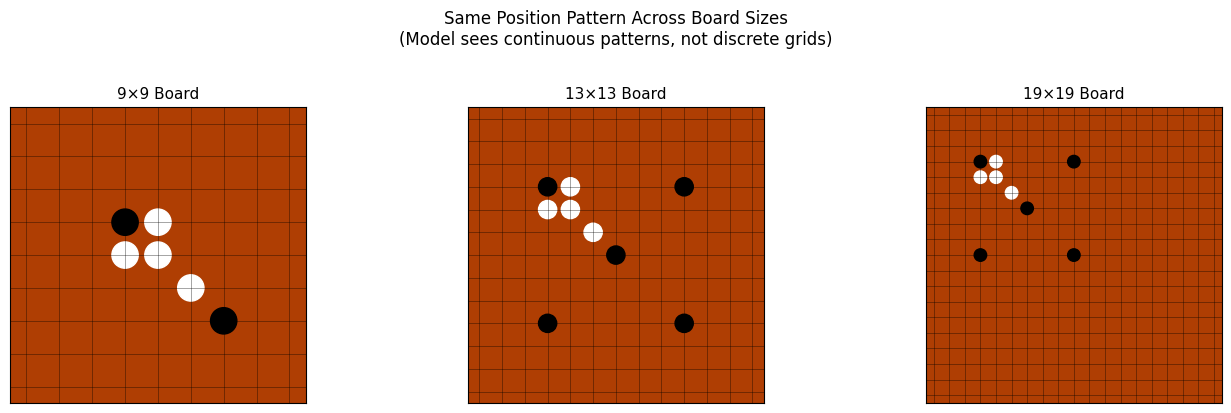

In [10]:
# Create and visualize sample boards using utility functions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

visualization_sizes = [9, 13, 19]

for idx, size in enumerate(visualization_sizes):
    # Create board using configurable positions
    board = create_sample_board(
        size=size,
        black_positions=config.go_board.black_stone_positions,
        white_positions=config.go_board.white_stone_positions,
        n_channels=config.model.input_channels,
        device='cpu',
    )
    
    ax = axes[idx]
    plot_go_board(
        board=board,
        ax=ax,
        stone_radius=config.go_board.stone_radius,
        board_color=config.go_board.board_color,
        grid_alpha=config.go_board.grid_alpha,
        grid_linewidth=config.go_board.grid_linewidth,
    )
    ax.set_title(f'{size}×{size} Board', fontsize=11)

fig.suptitle('Same Position Pattern Across Board Sizes\n(Model sees continuous patterns, not discrete grids)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

2026-01-27 07:52:03 [debug    ] created_sample_board           n_black=2 n_white=4 size=9
2026-01-27 07:52:03 [debug    ] created_sample_board           n_black=5 n_white=4 size=13
2026-01-27 07:52:03 [debug    ] created_sample_board           n_black=5 n_white=4 size=19


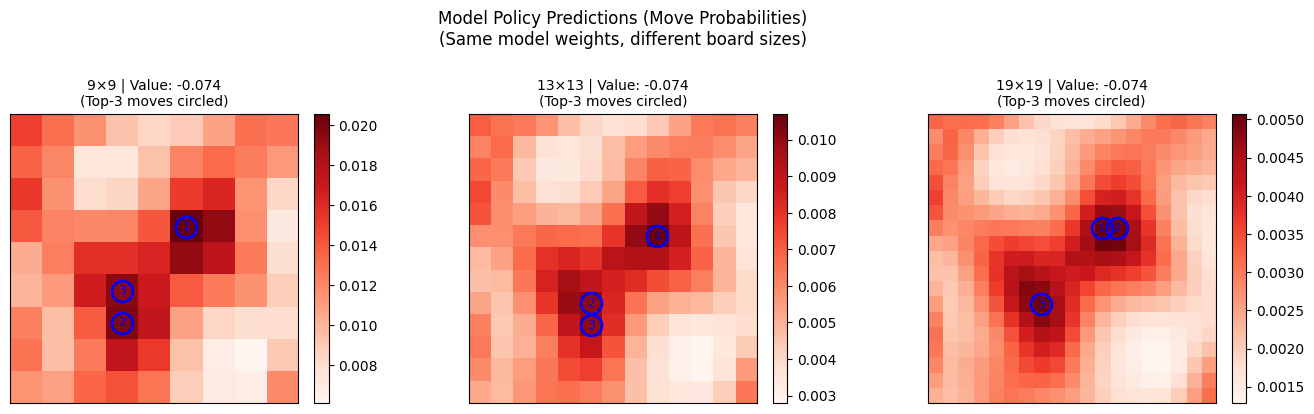

In [11]:
# Show model predictions on these boards
model.eval()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, size in enumerate(visualization_sizes):
    board = create_sample_board(
        size=size,
        black_positions=config.go_board.black_stone_positions,
        white_positions=config.go_board.white_stone_positions,
        n_channels=config.model.input_channels,
        device=device,
    )
    
    # Safe forward pass
    result = safe_model_forward(model, board)
    
    ax = axes[idx]
    
    if result.success:
        # Plot policy heatmap
        im = plot_policy_heatmap(
            policy_logits=result.policy_logits,
            board_size=size,
            ax=ax,
            top_k=3,
            cmap=config.visualization.colormap_hot,
        )
        
        value = result.value.item()
        ax.set_title(f'{size}×{size} | Value: {value:.3f}\n(Top-3 moves circled)', fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.text(0.5, 0.5, f'Error: {result.error}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{size}×{size} | Error', fontsize=10)

fig.suptitle('Model Policy Predictions (Move Probabilities)\n(Same model weights, different board sizes)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---

# Summary

## Key Innovations

1. **Resolution Independence**: Train on 9×9, play on 19×19
2. **O(N) Galerkin Attention**: Global influence without quadratic cost
3. **FNet Acceleration**: Fast rollouts for MCTS
4. **Mathematical Foundation**: Petrov-Galerkin projection, Green's functions

## Applications Beyond Go

The continuous operator approach generalizes to:
- **Physics Simulation**: PDEs, fluid dynamics
- **Medical Imaging**: Resolution-independent analysis
- **Climate Models**: Multi-scale predictions
- **Any Grid-Based Game**: Chess variants, Hex, etc.

---

*AlphaGalerkin — Where Numerical Analysis Meets Game AI*

In [12]:
# Final summary
print("\n" + "="*60)
print("         AlphaGalerkin Demo Complete!")
print("="*60)
print("""
Key Takeaways:

  ✓ Same model works on ANY board size (5×5 to 25×25+)
  ✓ Galerkin attention is O(N) vs O(N²) softmax
  ✓ Physics validation: MSE 0.0002 on 19×19 (trained on 9×9)
  ✓ Dual architecture: Full model + Fast rollout model

Next Steps:
  • Train on Go self-play data
  • Scale to 19×19 competitive play
  • Explore multi-game transfer

For more: github.com/ianshank/AlphaGalerkin
""")
logger.info("notebook_complete")


         AlphaGalerkin Demo Complete!

Key Takeaways:

  ✓ Same model works on ANY board size (5×5 to 25×25+)
  ✓ Galerkin attention is O(N) vs O(N²) softmax
  ✓ Physics validation: MSE 0.0002 on 19×19 (trained on 9×9)
  ✓ Dual architecture: Full model + Fast rollout model

Next Steps:
  • Train on Go self-play data
  • Scale to 19×19 competitive play
  • Explore multi-game transfer

For more: github.com/ianshank/AlphaGalerkin

2026-01-27 07:52:04 [info     ] notebook_complete             
